# Lab 4: Linear Models

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Setup plots
%matplotlib inline
sns.set_theme()
np.random.seed(42)

---
## Exercise 1: Simple Linear Regression

In this exercise, we generate a synthetic dataset with a single feature and apply a linear regression model.

### Steps:
1. Generate a synthetic dataset using `make_regression` from `sklearn.datasets`.
2. Split the data into training and test sets.
3. Train a `LinearRegression` model on the training data.
4. Make predictions on the test data.
5. Visualize the results by plotting actual data points and the regression line.
6. Evaluate the model using R² and Mean Squared Error (MSE).

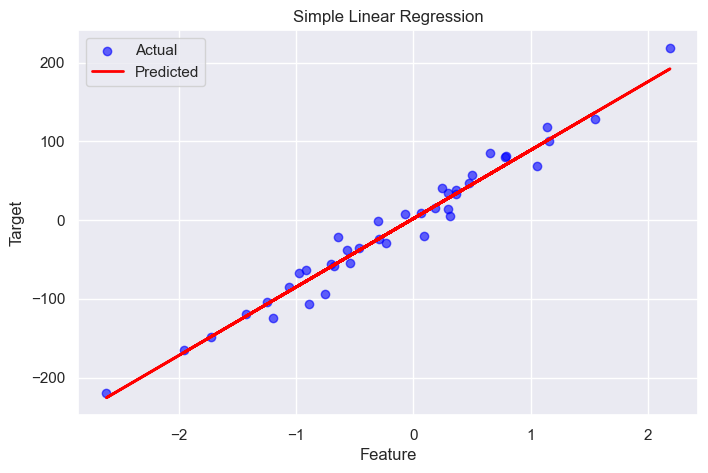

R² Score: 0.9681
Mean Squared Error: 246.1218
Coefficient (slope): 86.8180
Intercept: 1.8346


In [2]:
# Solution
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression

# 1. Generate synthetic data
X, y = make_regression(n_samples=200, n_features=1, noise=15, random_state=42)

# 2. Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Make predictions
y_pred = model.predict(X_test)

# 5. Visualize
plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, color='blue', alpha=0.6, label='Actual')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicted')
plt.xlabel('Feature')
plt.ylabel('Target')
plt.title('Simple Linear Regression')
plt.legend()
plt.show()

# 6. Evaluate
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.4f}")
print(f"Coefficient (slope): {model.coef_[0]:.4f}")
print(f"Intercept: {model.intercept_:.4f}")

**Question 1:** What do the R² score and MSE tell us about the model's performance? What does the coefficient represent geometrically?

**Answer:**

- **The coefficient (slope):** geometrically, it represents the slope of the regression line — how much the target variable changes for a one-unit increase in the feature. The intercept is where the line crosses the y-axis when the feature is zero.

- **R² (coefficient of determination):** measures the proportion of variance in the target variable that is explained by the model. An R² of 1.0 means perfect prediction; an R² of 0 means the model is no better than predicting the mean. Here we expect a high R² since the data is generated from a linear relationship with moderate noise.

- **MSE (Mean Squared Error):** measures the average squared difference between predicted and actual values. Lower is better. It is sensitive to outliers because errors are squared.

---
## Exercise 2: Multiple Linear Regression

Now we work with a real-world dataset: the **diabetes dataset** from scikit-learn. It has 10 numerical features and a quantitative target measuring disease progression.

### Steps:
1. Load the diabetes dataset.
2. Split into training and test sets.
3. Train a `LinearRegression` model.
4. Evaluate performance with R² and MSE.
5. Display the model coefficients to see which features are most important.

Dataset shape: (442, 10)
Features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

R² Score: 0.4526
Mean Squared Error: 2900.1936

Model coefficients:
Feature  Coefficient
     s1  -931.488846
     s5   736.198859
    bmi   542.428759
     s2   518.062277
     bp   347.703844
     s4   275.317902
    sex  -241.964362
     s3   163.419983
     s6    48.670657
    age    37.904021


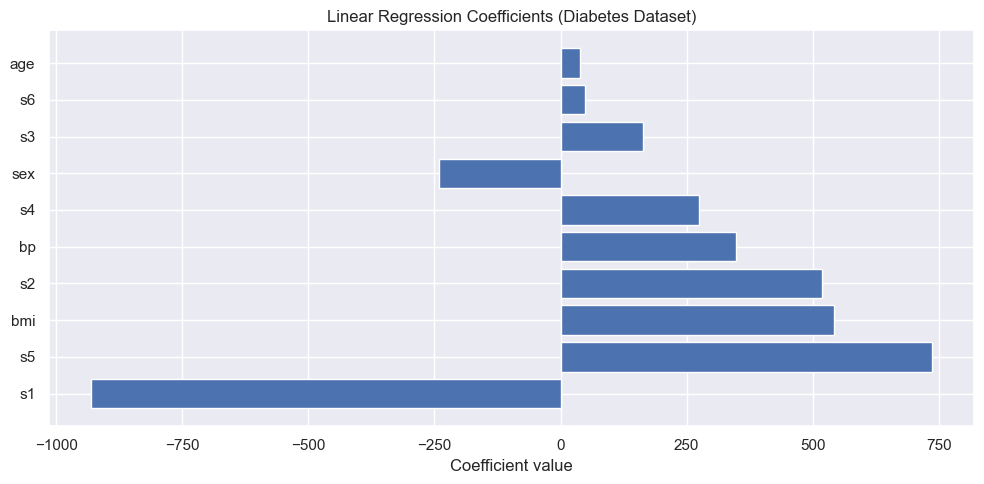

In [3]:
# Solution
from sklearn.datasets import load_diabetes

# 1. Load the dataset
diabetes = load_diabetes()
X, y = diabetes.data, diabetes.target
feature_names = diabetes.feature_names

print(f"Dataset shape: {X.shape}")
print(f"Features: {feature_names}")

# 2. Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Evaluate
y_pred = model.predict(X_test)
print(f"\nR² Score: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.4f}")

# 5. Display coefficients
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': model.coef_})
coef_df = coef_df.sort_values('Coefficient', key=abs, ascending=False)
print(f"\nModel coefficients:")
print(coef_df.to_string(index=False))

# Visualize coefficients
plt.figure(figsize=(10, 5))
plt.barh(coef_df['Feature'], coef_df['Coefficient'])
plt.xlabel('Coefficient value')
plt.title('Linear Regression Coefficients (Diabetes Dataset)')
plt.tight_layout()
plt.show()

**Question 2:** Which features have the largest impact on disease progression? Are any coefficients negative? What does a negative coefficient mean?

**Answer:**

- Note: since the diabetes dataset features are already standardized, the magnitude of the coefficients can be directly compared to assess relative importance.

- The features with the largest absolute coefficients have the most impact. Typically, `s5` (a blood serum measurement) and `bmi` (body mass index) have the largest positive coefficients, meaning they are most positively associated with disease progression.

- Yes, several coefficients are negative (e.g., `s1`). A **negative coefficient** means that as that feature increases, the predicted disease progression **decreases**, all else being equal. This is an inverse relationship.

---
## Exercise 3: Regularization — Ridge and Lasso

Regularization adds a penalty to the loss function to reduce model complexity and prevent overfitting.

### Ridge Regression (L2 penalty)
$$J(\theta) = \sum_{i=1}^{m}(y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^{n} \theta_j^2$$

Ridge shrinks coefficients towards zero but does not set them exactly to zero.

### Lasso Regression (L1 penalty)
$$J(\theta) = \sum_{i=1}^{m}(y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^{n} |\theta_j|$$

Lasso can set some coefficients exactly to zero, performing **feature selection**.

### Steps:
1. Load the California Housing dataset.
2. Train LinearRegression, Ridge, and Lasso models.
3. Compare their R² scores.
4. Study the effect of the regularization parameter $\alpha$.
5. Compare model coefficients.

In [4]:
# Solution
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# 1. Load the dataset
housing = fetch_california_housing()
X, y = housing.data, housing.target
feature_names = housing.feature_names

print(f"Dataset shape: {X.shape}")
print(f"Features: {feature_names}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Dataset shape: (20640, 8)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [5]:
# 2 & 3. Train and compare models
# Note: we use StandardScaler because regularization is sensitive to feature scale

models = {
    'Linear Regression': make_pipeline(StandardScaler(), LinearRegression()),
    'Ridge (alpha=1.0)': make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    'Lasso (alpha=0.1)': make_pipeline(StandardScaler(), Lasso(alpha=0.1)),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"{name:30s} — R²: {r2_score(y_test, y_pred):.4f}, MSE: {mean_squared_error(y_test, y_pred):.4f}")

Linear Regression              — R²: 0.5758, MSE: 0.5559
Ridge (alpha=1.0)              — R²: 0.5758, MSE: 0.5559
Lasso (alpha=0.1)              — R²: 0.4814, MSE: 0.6796


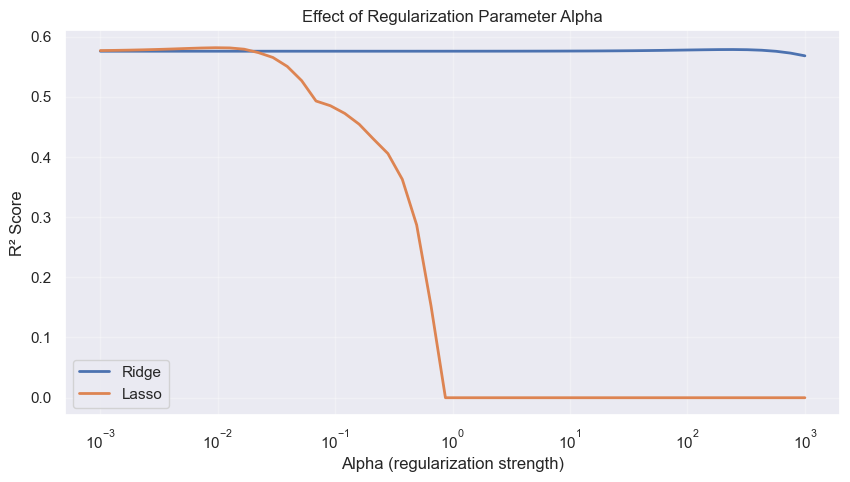

In [6]:
# 4. Study the effect of alpha
alphas = np.logspace(-3, 3, 50)
ridge_scores = []
lasso_scores = []

for alpha in alphas:
    ridge = make_pipeline(StandardScaler(), Ridge(alpha=alpha))
    ridge.fit(X_train, y_train)
    ridge_scores.append(r2_score(y_test, ridge.predict(X_test)))
    
    lasso = make_pipeline(StandardScaler(), Lasso(alpha=alpha, max_iter=10000))
    lasso.fit(X_train, y_train)
    lasso_scores.append(r2_score(y_test, lasso.predict(X_test)))

plt.figure(figsize=(10, 5))
plt.plot(alphas, ridge_scores, label='Ridge', linewidth=2)
plt.plot(alphas, lasso_scores, label='Lasso', linewidth=2)
plt.xscale('log')
plt.xlabel('Alpha (regularization strength)')
plt.ylabel('R² Score')
plt.title('Effect of Regularization Parameter Alpha')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

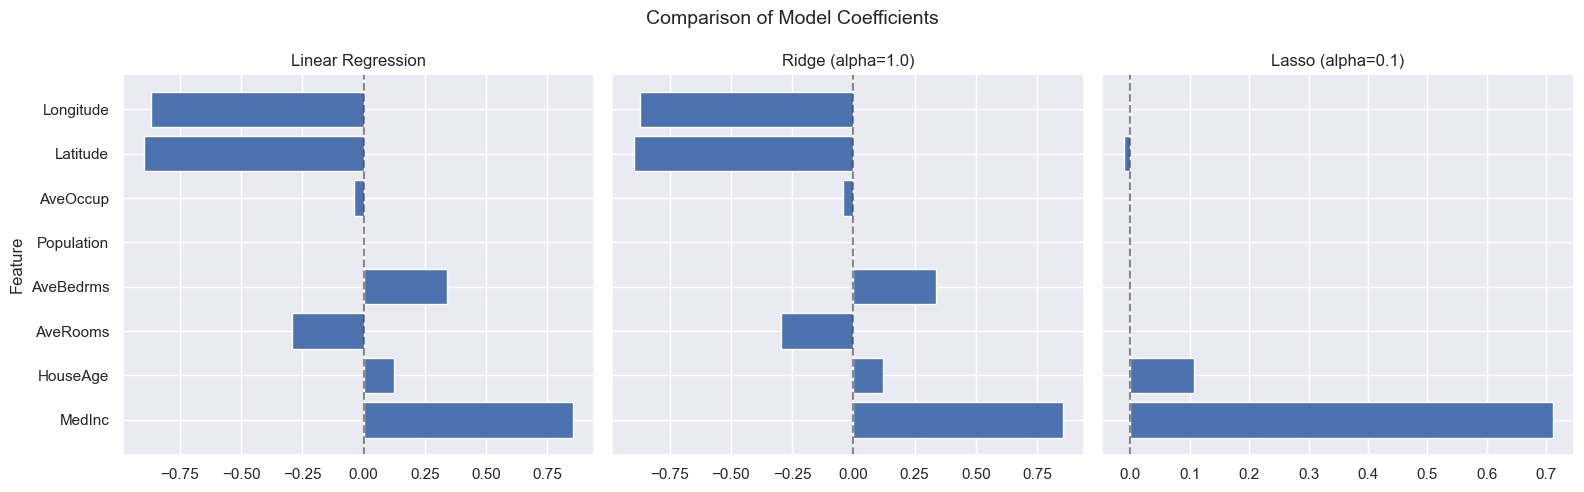

Features set to zero by Lasso: ['AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Longitude']


In [7]:
# 5. Compare coefficients
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, (name, model) in zip(axes, models.items()):
    # The regression model is the second step of the pipeline (after StandardScaler)
    coefs = model[1].coef_
    ax.barh(feature_names, coefs)
    ax.set_title(name)
    ax.axvline(x=0, color='k', linestyle='--', alpha=0.5)

axes[0].set_ylabel('Feature')
fig.suptitle('Comparison of Model Coefficients', fontsize=14)
plt.tight_layout()
plt.show()

# Show which coefficients Lasso set to zero
lasso_model = models['Lasso (alpha=0.1)'][1]
zero_coefs = [f for f, c in zip(feature_names, lasso_model.coef_) if abs(c) < 1e-10]
print(f"Features set to zero by Lasso: {zero_coefs if zero_coefs else 'None (try a larger alpha)'}")

**Question 3:** 
- What happens to model performance when alpha is too large? Too small?
- What is the key difference between Ridge and Lasso in terms of feature selection?
- Why do we need to standardize features before applying regularization?

**Answer:**

- **Why standardize:** Regularization penalizes the magnitude of coefficients. If features have very different scales (e.g., one ranges from 0–1 and another from 0–10,000), the penalty will disproportionately affect features with larger scales. Standardization ensures all features contribute equally to the penalty term.

- **Alpha too large:** the penalty dominates the loss function, shrinking all coefficients toward zero. The model becomes too simple and **underfits** (low R² on both training and test data).

- **Ridge vs Lasso for feature selection:** Ridge (L2) shrinks all coefficients toward zero but never sets them exactly to zero. Lasso (L1) can set some coefficients to exactly zero, effectively performing **automatic feature selection**. This makes Lasso models more interpretable when many features are irrelevant.

- **Alpha too small:** the regularization has almost no effect, so the model behaves like ordinary linear regression and may **overfit** if the dataset has many features or noise.

---
## Exercise 4: Logistic Regression for Classification

Logistic regression is used for **classification** tasks. Despite its name, it is not a regression model — it predicts the probability that an observation belongs to a given class.

### Steps:
1. Generate a 2D synthetic classification dataset.
2. Train a logistic regression model.
3. Visualize the decision boundary.
4. Compute the confusion matrix.

In [8]:
# Solution
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

# 1. Generate synthetic 2D data
X_class, y_class = make_classification(
    n_samples=300, n_features=2, n_redundant=0,
    n_informative=2, n_clusters_per_class=1, random_state=42
)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class, y_class, test_size=0.3, random_state=42
)

# 2. Train logistic regression
log_reg = LogisticRegression()
log_reg.fit(X_train_c, y_train_c)

print(f"Model weights: {log_reg.coef_}")
print(f"Bias: {log_reg.intercept_}")
print(f"Accuracy: {log_reg.score(X_test_c, y_test_c):.4f}")

Model weights: [[0.60971674 3.12280777]]
Bias: [-0.46354358]
Accuracy: 0.9556


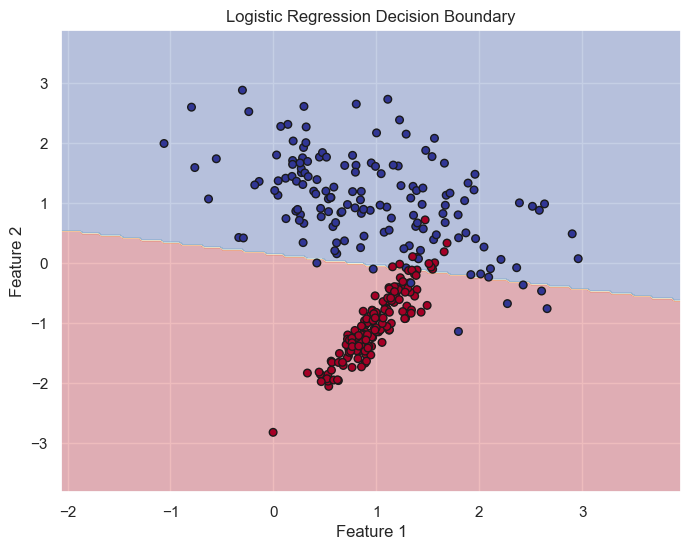

In [9]:
# 3. Visualize the decision boundary
def plot_decision_boundary(model, X, y, title="Decision Boundary"):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.RdYlBu, s=30)
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')

plt.figure(figsize=(8, 6))
plot_decision_boundary(log_reg, X_class, y_class, "Logistic Regression Decision Boundary")
plt.show()

In [10]:
# 4. Confusion matrix
y_pred_c = log_reg.predict(X_test_c)

cm = confusion_matrix(y_test_c, y_pred_c)
cm_df = pd.DataFrame(cm, index=["Actual 0", "Actual 1"], columns=["Predicted 0", "Predicted 1"])
print("Confusion Matrix:")
print(cm_df)

print("\nClassification Report:")
print(classification_report(y_test_c, y_pred_c))

Confusion Matrix:
          Predicted 0  Predicted 1
Actual 0           44            2
Actual 1            2           42

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        46
           1       0.95      0.95      0.95        44

    accuracy                           0.96        90
   macro avg       0.96      0.96      0.96        90
weighted avg       0.96      0.96      0.96        90



**Question 4:**
- What does each cell in the confusion matrix represent (TP, FP, TN, FN)?
- In what situations would you prefer to optimize recall over precision?

**Answer:**

- **Optimizing recall over precision:** when the cost of missing a positive case is very high. For example, in **medical diagnosis** (e.g., cancer screening), missing a sick patient (false negative) is far worse than a false alarm (false positive). In fraud detection, failing to detect fraud is more costly than flagging a legitimate transaction for review.

- **Confusion matrix cells:**
  - **True Positives (TP):** samples correctly predicted as positive (top-left for class 0, or bottom-right for class 1, depending on convention).  
  
  - **False Negatives (FN):** samples incorrectly predicted as negative (the model missed them).

  - **False Positives (FP):** samples incorrectly predicted as positive (the model said positive, but they were actually negative).  
  
  - **True Negatives (TN):** samples correctly predicted as negative.

---
## Exercise 5: Poisson Regression — Modeling World Population Growth

### Background: Why not just use linear regression?

In standard linear regression, we model the target as a linear function of the features:

$$h_\theta(X) = X\theta = \theta_0 + \theta_1 x_1 + \cdots + \theta_n x_n$$

This works well when the target can take any real value. But for **population data**, we have two problems:
1. Population is always **positive** — linear regression could predict negative values.
2. Population growth is **exponential**, not linear — a straight line is a poor fit.

### The idea behind Poisson regression

Instead of predicting the target directly as a linear combination, we assume that the **logarithm** of the target is linear:

$$\log(h_\theta(X)) = X\theta$$

Equivalently, the prediction (hypothesis) is:

$$h_\theta(X) = \exp(X\theta) = \exp(\theta_0 + \theta_1 x_1 + \cdots + \theta_n x_n)$$

This guarantees that predictions are always **positive** and naturally captures **exponential** trends.

### Notation

- $X \in \mathbb{R}^{m \times (n+1)}$ is the feature matrix ($m$ samples, $n$ features + 1 bias column of ones)
- $\theta \in \mathbb{R}^{(n+1) \times 1}$ is the parameter vector (intercept $\theta_0$ + coefficients $\theta_1, \ldots, \theta_n$)
- $y \in \mathbb{R}^m$ is the target vector (here, population counts)

In our case, we have a single feature ($n = 1$): the year. So the model is simply:

$$h_\theta(\text{year}) = \exp(\theta_0 + \theta_1 \times \text{year})$$

The parameter $\theta_1$ controls the **growth rate**: a positive $\theta_1$ means exponential growth.

### Why is it called Poisson regression?

The [Poisson distribution](https://en.wikipedia.org/wiki/Poisson_distribution) is a probability distribution for count data ($0, 1, 2, \ldots$) with parameter $\lambda > 0$. In Poisson regression, we model the expected count as $\lambda = \exp(X\theta)$. The name comes from the statistical assumption on the distribution of the target, but in practice, the key idea is simply: **use an exponential link to ensure positive predictions**.

### Steps:
1. Load world population data from the CSV file.
2. Visualize the data (linear and log scale).
3. Fit a Poisson regression model using scikit-learn.
4. Evaluate the model and visualize predictions.
5. Make future population projections and discuss their limitations.

In [11]:
# Solution

# 1. Load world population data
pop_df = pd.read_csv("population-regions-with-projections.csv")

# Filter for world-level data
world = pop_df[pop_df["Entity"] == "World"].copy()
world = world.sort_values("Year")

print(f"World population data: {world.shape[0]} entries")
print(f"Year range: {world['Year'].min()} to {world['Year'].max()}")
world.tail(10)

World population data: 338 entries
Year range: -10000 to 2100


,Entity,Code,Year,Population
77171,World,OWID_WRL,2091,10419647488
77172,World,OWID_WRL,2092,10414959616
77173,World,OWID_WRL,2093,10409491456
77174,World,OWID_WRL,2094,10403271680
77175,World,OWID_WRL,2095,10396305408
77176,World,OWID_WRL,2096,10388516864
77177,World,OWID_WRL,2097,10379888640
77178,World,OWID_WRL,2098,10370445312
77179,World,OWID_WRL,2099,10360269824
77180,World,OWID_WRL,2100,10349323264


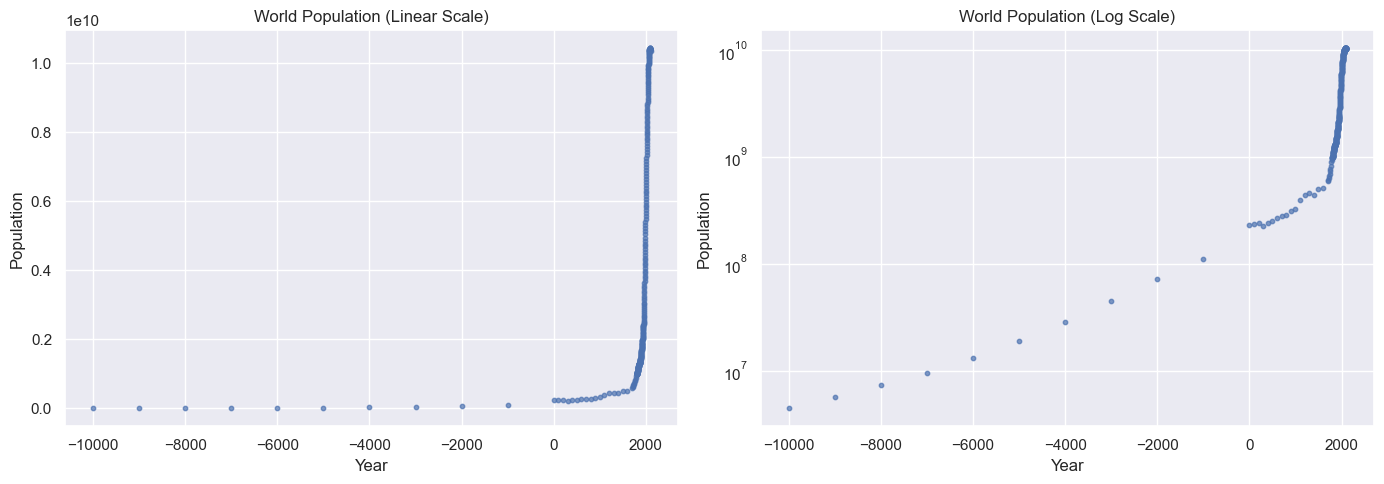

In [12]:
# 2. Visualize the data
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(world["Year"], world["Population"], s=10, alpha=0.7)
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Population")
axes[0].set_title("World Population (Linear Scale)")

axes[1].scatter(world["Year"], world["Population"], s=10, alpha=0.7)
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Population")
axes[1].set_yscale("log")
axes[1].set_title("World Population (Log Scale)")

plt.tight_layout()
plt.show()

We restrict the data to years $\geq 1700$.

In [13]:
# 3. Fit a Poisson regression model (years >= 1700)
from sklearn.linear_model import PoissonRegressor

world_modern = world[world["Year"] >= 1700].copy()
Years = world_modern[["Year"]].values
Pop = world_modern["Population"].values

print(f"Data points (years >= 1700): {len(Pop)}")

poisson_model = PoissonRegressor(solver="newton-cholesky", alpha=0)
poisson_model.fit(Years, Pop)

print(f"\nTheta_0 (intercept): {poisson_model.intercept_:.6f}")
print(f"Theta_1 (coefficient): {poisson_model.coef_[0]:.6f}")
print(f"R² score: {r2_score(Pop, poisson_model.predict(Years)):.6f}")

Data points (years >= 1700): 311

Theta_0 (intercept): 3.235878
Theta_1 (coefficient): 0.009575
R² score: 0.938239


/Users/nath/Documents/Teaching/MachineLearningCourse2026/.venv/lib/python3.14/site-packages/sklearn/linear_model/_glm/_newton_solver.py:289: ConvergenceWarning: Line search of Newton solver NewtonCholeskySolver at iteration #7 did no converge after 21 line search refinement iterations. It will now resort to lbfgs instead.
  warnings.warn(


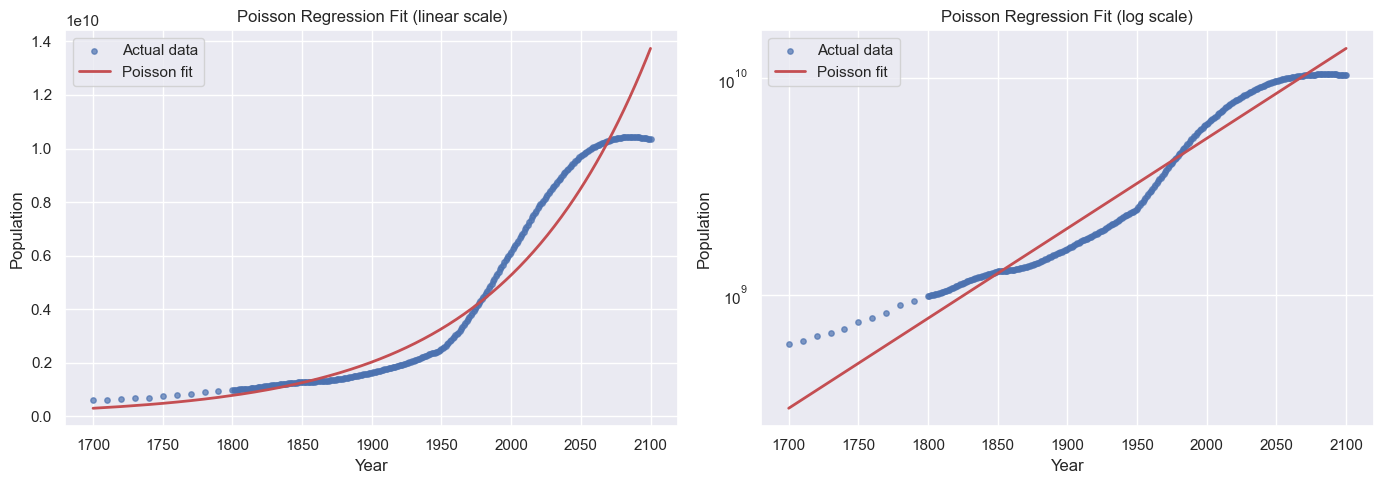

In [14]:
# 4. Visualize the fit
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, scale in zip(axes, ['linear', 'log']):
    ax.scatter(Years, Pop, s=15, alpha=0.7, label='Actual data')
    ax.plot(Years, poisson_model.predict(Years), 'r-', linewidth=2, label='Poisson fit')
    ax.set_xlabel("Year")
    ax.set_ylabel("Population")
    ax.set_yscale(scale)
    ax.set_title(f"Poisson Regression Fit ({scale} scale)")
    ax.legend()

plt.tight_layout()
plt.show()

In [15]:
# 5. Make future projections
future_years = np.array([[2030], [2050], [2100], [2200]])
predictions = poisson_model.predict(future_years)

print("Population projections (Poisson model):")
print("=" * 40)
for year, pop in zip(future_years.ravel(), predictions):
    print(f"  Year {year}: {pop/1e9:.2f} billion")

Population projections (Poisson model):
  Year 2030: 7.03 billion
  Year 2050: 8.51 billion
  Year 2100: 13.74 billion
  Year 2200: 35.79 billion


**Question 5:**
- What alternative name could you give to Poisson regression, based on its hypothesis function $h_\theta(X) = \exp(X\theta)$?
- Why might the model's far-future projections be inaccurate?


**Answer:**

- **Alternative name:** Since the hypothesis function is $h_\theta(X) = \exp(X\theta)$, Poisson regression could reasonably be called **"exponential regression"**.

- **Inaccurate far-future projections:** The model assumes that the exponential growth rate observed since 1700 continues indefinitely. In reality, population growth rates have been **declining** since the mid-20th century due to demographic transitions (lower birth rates, urbanization, education). Real population models (e.g., UN projections) predict that world population will plateau around 10–11 billion. The simple Poisson model has no mechanism to capture this slowdown.